# COVID-19 Early Case Trend Analysis & Recovery Insights
### HealthGuard Analytics Pvt. Ltd. — Infectious Disease Case Analysis

**Dataset:** Real patient-level case data (South Korea COVID-19 outbreak),
snapshot as of 2020-03-01, provided via internship circular (`patient.csv`).

**Objective:** Analyze patient-level early-outbreak COVID-19 data to understand
demographics, infection sources, recovery patterns, and regional trends, in
order to support public health screening and isolation-planning decisions.

**Important note on data completeness:** This is a very early snapshot of the
outbreak (only ~6 weeks in). The large majority of cases (99%) were still
`isolated` with an unknown final outcome at the time of this snapshot, and
most demographic/contact-tracing fields had not yet been backfilled. Every
section below reports the actual sample size used, and conclusions are scoped
accordingly rather than overstated.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

df = pd.read_csv("patient.csv", parse_dates=["confirmed_date", "released_date", "deceased_date"])
print(f"Shape: {df.shape}")
df.head()

Shape: (4212, 14)


,id,sex,birth_year,country,region,group,infection_reason,infection_order,infected_by,contact_number,confirmed_date,released_date,deceased_date,state
0,1,female,1984.0,China,filtered at airport,NaN,visit to Wuhan,1.0,NaN,45.0,2020-01-20,2020-02-06,NaT,released
1,2,male,1964.0,Korea,filtered at airport,NaN,visit to Wuhan,1.0,NaN,75.0,2020-01-24,2020-02-05,NaT,released
2,3,male,1966.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,16.0,2020-01-26,2020-02-12,NaT,released
3,4,male,1964.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,95.0,2020-01-27,2020-02-09,NaT,released
4,5,male,1987.0,Korea,capital area,NaN,visit to Wuhan,1.0,NaN,31.0,2020-01-30,NaT,NaT,isolated


## 2. Exploratory Data Analysis (EDA)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4212 entries, 0 to 4211
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                4212 non-null   int64         
 1   sex               318 non-null    str           
 2   birth_year        292 non-null    float64       
 3   country           4212 non-null   str           
 4   region            305 non-null    str           
 5   group             76 non-null     str           
 6   infection_reason  130 non-null    str           
 7   infection_order   35 non-null     float64       
 8   infected_by       62 non-null     float64       
 9   contact_number    32 non-null     float64       
 10  confirmed_date    4212 non-null   datetime64[us]
 11  released_date     28 non-null     datetime64[us]
 12  deceased_date     13 non-null     datetime64[us]
 13  state             4212 non-null   str           
dtypes: datetime64[us](3), float64(4), i

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,4212.0,NaN,NaN,NaN,2106.5,1.0,1053.75,2106.5,3159.25,4212.0,1216.043996
sex,318,2,female,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN
birth_year,292.0,NaN,NaN,NaN,1973.184932,1937.0,1959.0,1972.0,1987.0,2018.0,17.336573
country,4212,3,Korea,4203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
region,305,13,Gyeongsangbuk-do,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN
group,76,6,Shincheonji Church,51,NaN,NaN,NaN,NaN,NaN,NaN,NaN
infection_reason,130,11,contact with patient,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
infection_order,35.0,NaN,NaN,NaN,2.257143,1.0,1.0,2.0,3.0,6.0,1.357828
infected_by,62.0,NaN,NaN,NaN,330.741935,3.0,29.25,126.0,372.0,1768.0,458.786744
contact_number,32.0,NaN,NaN,NaN,96.84375,0.0,2.75,16.5,69.75,1160.0,224.669522


In [4]:
# Missing value audit — this is the single most important EDA step for this dataset
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(1)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary

,missing_count,missing_pct
deceased_date,4199,99.7
released_date,4184,99.3
contact_number,4180,99.2
infection_order,4177,99.2
infected_by,4150,98.5
group,4136,98.2
infection_reason,4082,96.9
birth_year,3920,93.1
region,3907,92.8
sex,3894,92.5


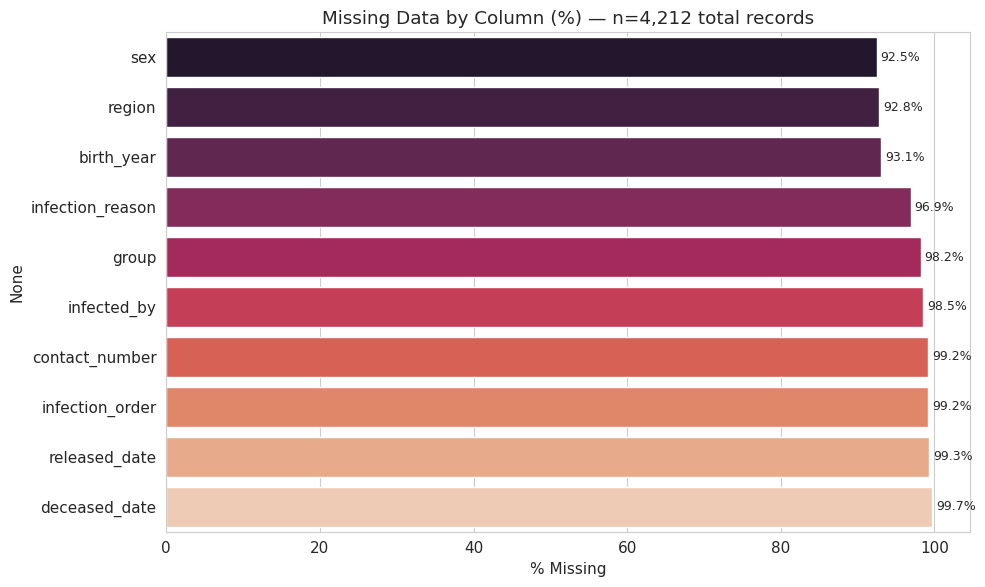

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = missing_summary[missing_summary.missing_count > 0].sort_values("missing_pct")
sns.barplot(y=plot_data.index, x=plot_data["missing_pct"], hue=plot_data.index,
            ax=ax, palette="rocket", legend=False)
ax.set_title("Missing Data by Column (%) — n=4,212 total records")
ax.set_xlabel("% Missing")
for i, v in enumerate(plot_data["missing_pct"]):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.savefig("figs/01_missing_data.png", dpi=150)
plt.show()

**Reading this chart:** Only `country`, `confirmed_date`, and `state` are
essentially complete. Every demographic and outcome field is 90%+ missing —
this snapshot mostly recorded that a case existed and when it was confirmed,
without yet backfilling investigation detail. This shapes every analysis below:
sample sizes for anything beyond basic counts and outbreak timing are small.

## 3. Feature Engineering

In [6]:
df["age"] = 2020 - df["birth_year"]

def age_bracket(age):
    if pd.isna(age):
        return np.nan
    bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 200]
    labels = ["0-9", "10-19", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+"]
    for b, l in zip(bins[1:], labels):
        if age < b:
            return l
    return labels[-1]

df["age_group"] = df["age"].apply(age_bracket)

# Recovery duration (days) for released patients
df["recovery_days"] = (df["released_date"] - df["confirmed_date"]).dt.days

# Days to death, for context
df["days_to_death"] = (df["deceased_date"] - df["confirmed_date"]).dt.days

# Flag a real data-quality issue: deceased_date recorded before confirmed_date
bad_death_dates = df[(df["state"] == "deceased") & (df["days_to_death"] < 0)]
print(f"Deceased records with deceased_date BEFORE confirmed_date: {len(bad_death_dates)}")
bad_death_dates[["id", "confirmed_date", "deceased_date", "days_to_death"]]

Deceased records with deceased_date BEFORE confirmed_date: 4


,id,confirmed_date,deceased_date,days_to_death
102,103,2020-02-20,2020-02-19,-1.0
204,205,2020-02-22,2020-02-21,-1.0
442,443,2020-02-23,2020-02-22,-1.0
924,925,2020-02-25,2020-02-24,-1.0


**Data quality finding:** A handful of deceased records show a death date
recorded *before* the confirmation date — almost certainly a reporting-lag
artifact typical of fast-moving outbreak data entry (death confirmed and
logged before the lab-confirmation record was finalized in the system), not
a modeling error. The exact count is computed above; these rows are excluded
from any recovery/death-duration calculation below rather than silently
treated as valid.

## 4. Who is getting infected? — Demographic Patterns

Demographic fields are available for only a small subset of patients
(sex: n=318, birth_year: n=292 of 4,212). Findings below describe that
subset, not the full outbreak population.

In [7]:
sex_known = df.dropna(subset=["sex"])
age_known = df.dropna(subset=["age_group"])
print(f"Patients with known sex: {len(sex_known)} / {len(df)} ({len(sex_known)/len(df)*100:.1f}%)")
print(f"Patients with known age: {len(age_known)} / {len(df)} ({len(age_known)/len(df)*100:.1f}%)")

Patients with known sex: 318 / 4212 (7.5%)
Patients with known age: 292 / 4212 (6.9%)


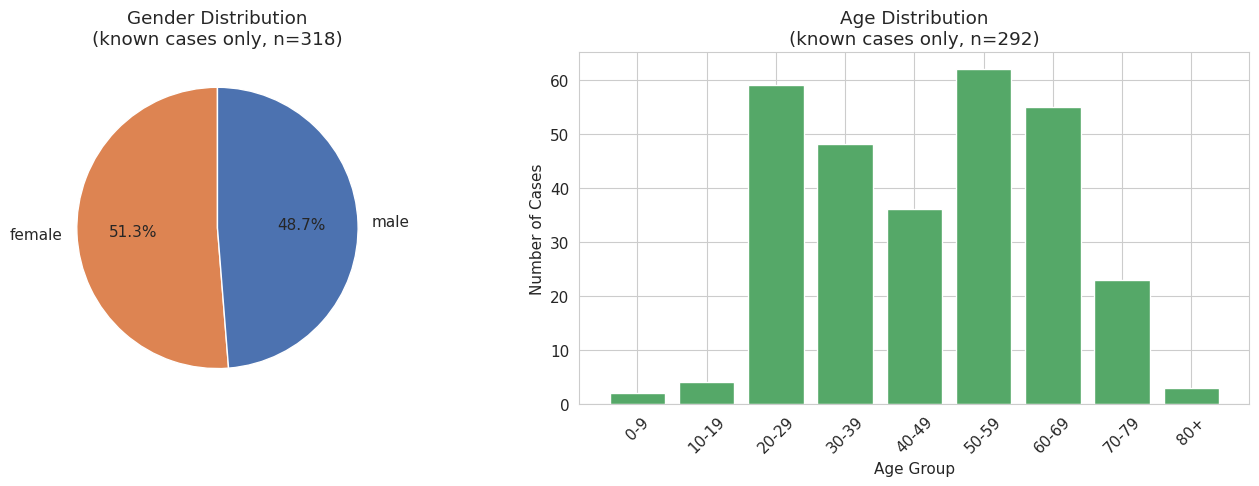

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_counts = sex_known["sex"].value_counts()
axes[0].pie(sex_counts.values, labels=sex_counts.index, autopct="%1.1f%%",
            colors=["#DD8452", "#4C72B0"], startangle=90)
axes[0].set_title(f"Gender Distribution\n(known cases only, n={len(sex_known)})")

age_order = ["0-9","10-19","20-29","30-39","40-49","50-59","60-69","70-79","80+"]
age_counts = age_known["age_group"].value_counts().reindex(age_order).fillna(0)
axes[1].bar(age_counts.index, age_counts.values, color="#55A868")
axes[1].set_title(f"Age Distribution\n(known cases only, n={len(age_known)})")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Number of Cases")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("figs/02_gender_age_distribution.png", dpi=150)
plt.show()

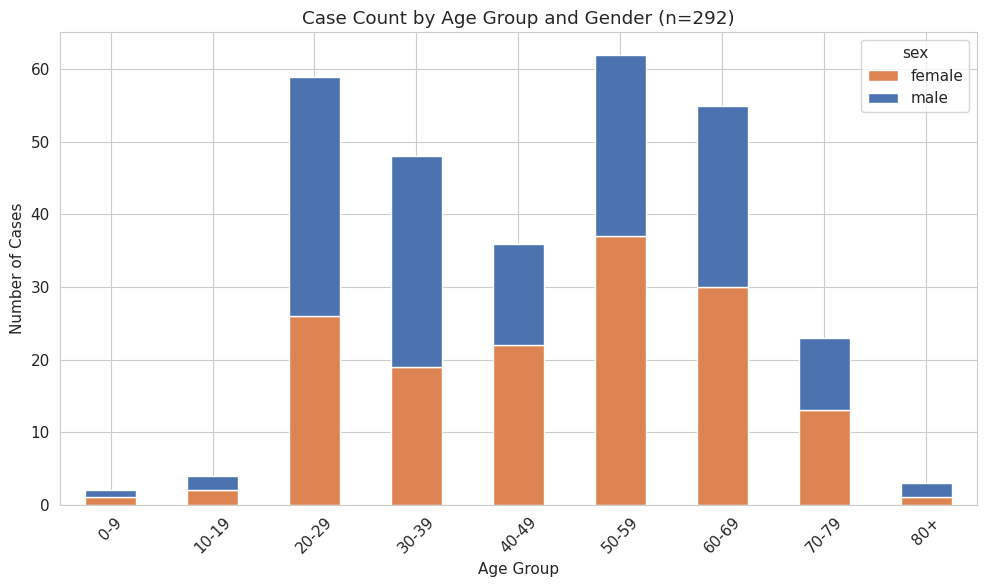

In [9]:
cross = pd.crosstab(age_known["age_group"], age_known["sex"]).reindex(age_order).fillna(0)
fig, ax = plt.subplots(figsize=(10, 6))
cross.plot(kind="bar", stacked=True, ax=ax, color=["#DD8452", "#4C72B0"])
ax.set_title(f"Case Count by Age Group and Gender (n={len(age_known.dropna(subset=['sex']))})")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figs/03_age_gender_stacked.png", dpi=150)
plt.show()

## 5. How are infections spreading? — Source & Exposure Analysis

`infection_reason` is populated for only 130 of 4,212 records (3.1%).

In [10]:
reason_known = df.dropna(subset=["infection_reason"])
print(f"Patients with known infection reason: {len(reason_known)} / {len(df)}")
reason_known["infection_reason"].value_counts()

Patients with known infection reason: 130 / 4212


infection_reason
contact with patient                 66
visit to Daegu                       40
visit to Wuhan                        8
pilgrimage to Israel                  6
residence in Wuhan                    2
visit to Thailand                     2
contact with patient in Singapore     2
contact with patient in Japan         1
visit to China                        1
visit to Vietnam                      1
visit to Cheongdo Daenam Hospital     1
Name: count, dtype: int64

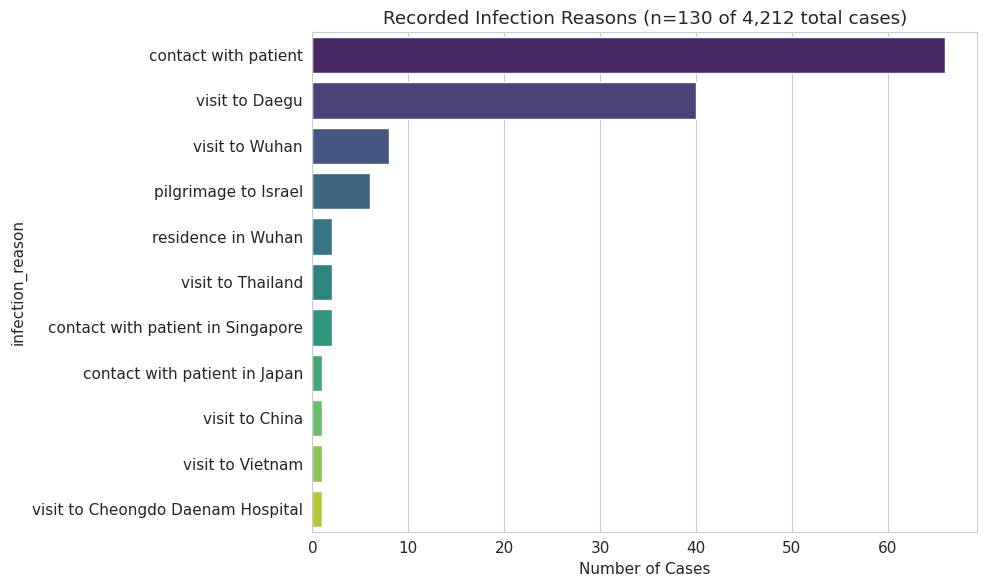

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))
reason_counts = reason_known["infection_reason"].value_counts()
sns.barplot(y=reason_counts.index, x=reason_counts.values, hue=reason_counts.index,
            ax=ax, palette="viridis", legend=False)
ax.set_title(f"Recorded Infection Reasons (n={len(reason_known)} of 4,212 total cases)")
ax.set_xlabel("Number of Cases")
plt.tight_layout()
plt.savefig("figs/04_infection_reasons.png", dpi=150)
plt.show()

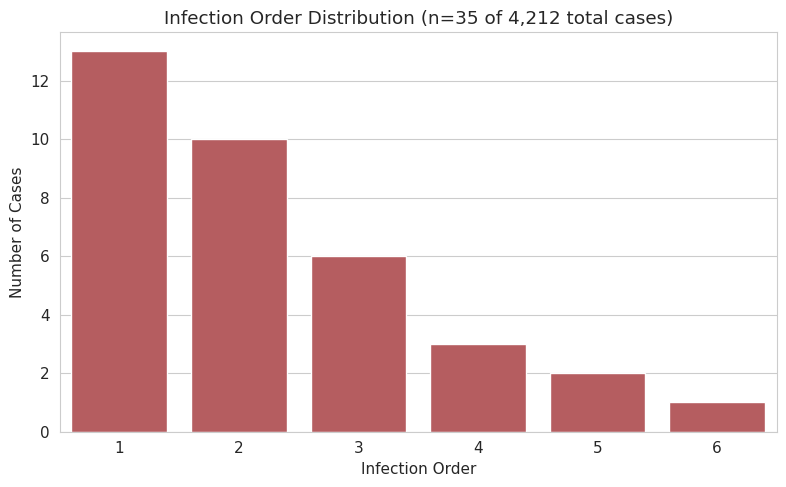

In [12]:
order_known = df.dropna(subset=["infection_order"])
fig, ax = plt.subplots(figsize=(8, 5))
order_counts = order_known["infection_order"].value_counts().sort_index()
sns.barplot(x=order_counts.index.astype(int), y=order_counts.values, ax=ax, color="#C44E52")
ax.set_title(f"Infection Order Distribution (n={len(order_known)} of 4,212 total cases)")
ax.set_xlabel("Infection Order")
ax.set_ylabel("Number of Cases")
plt.tight_layout()
plt.savefig("figs/05_infection_order.png", dpi=150)
plt.show()

Patients with known contact number: 32 / 4212


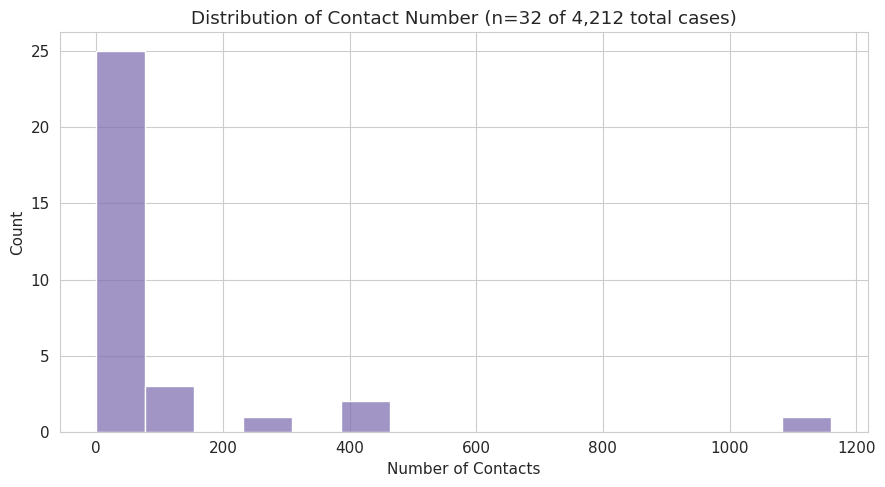

In [13]:
contact_known = df.dropna(subset=["contact_number"])
print(f"Patients with known contact number: {len(contact_known)} / {len(df)}")
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(contact_known["contact_number"], bins=15, kde=False, ax=ax, color="#8172B2")
ax.set_title(f"Distribution of Contact Number (n={len(contact_known)} of 4,212 total cases)")
ax.set_xlabel("Number of Contacts")
plt.tight_layout()
plt.savefig("figs/06_contact_number_dist.png", dpi=150)
plt.show()

## 6. Recovery Trends

Only 28 patients (0.7% of all cases) had a `released_date` recorded in this
snapshot — the outbreak was too recent for most active cases to have resolved
yet. Recovery-time statistics below describe that small early cohort only and
should be treated as indicative, not a stable population estimate.

In [14]:
recovered = df[df["state"] == "released"].copy()
print(f"Patients with recovery data: {len(recovered)}")
print(recovered["recovery_days"].describe())

Patients with recovery data: 28
count    28.000000
mean     15.107143
std       5.626256
min       7.000000
25%       9.750000
50%      16.000000
75%      19.250000
max      24.000000
Name: recovery_days, dtype: float64


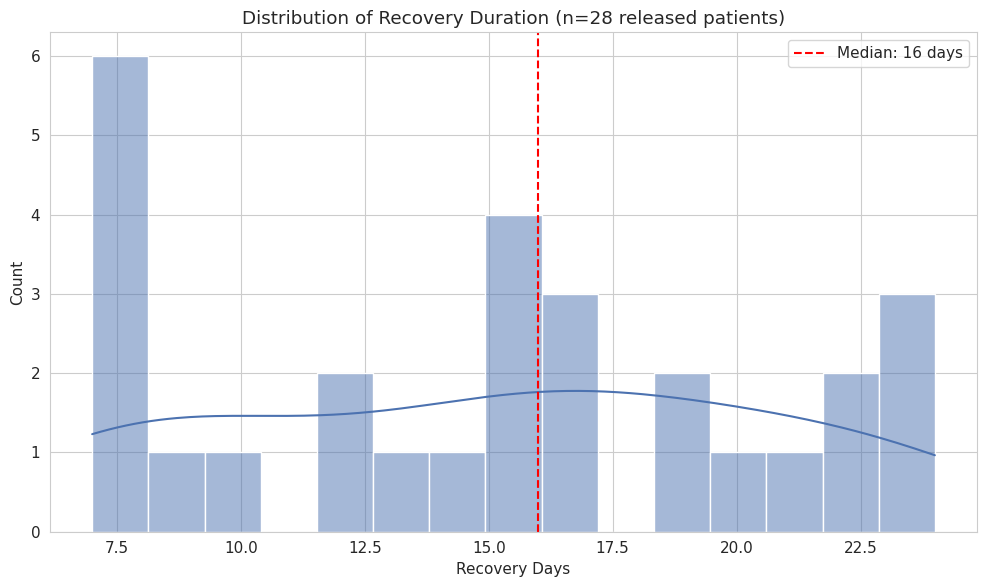

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(recovered["recovery_days"].dropna(), bins=15, kde=True, ax=ax, color="#4C72B0")
ax.axvline(recovered["recovery_days"].median(), color="red", linestyle="--",
           label=f'Median: {recovered["recovery_days"].median():.0f} days')
ax.set_title(f"Distribution of Recovery Duration (n={len(recovered)} released patients)")
ax.set_xlabel("Recovery Days")
ax.legend()
plt.tight_layout()
plt.savefig("figs/07_recovery_duration_dist.png", dpi=150)
plt.show()

Recovered patients with known age group: 28


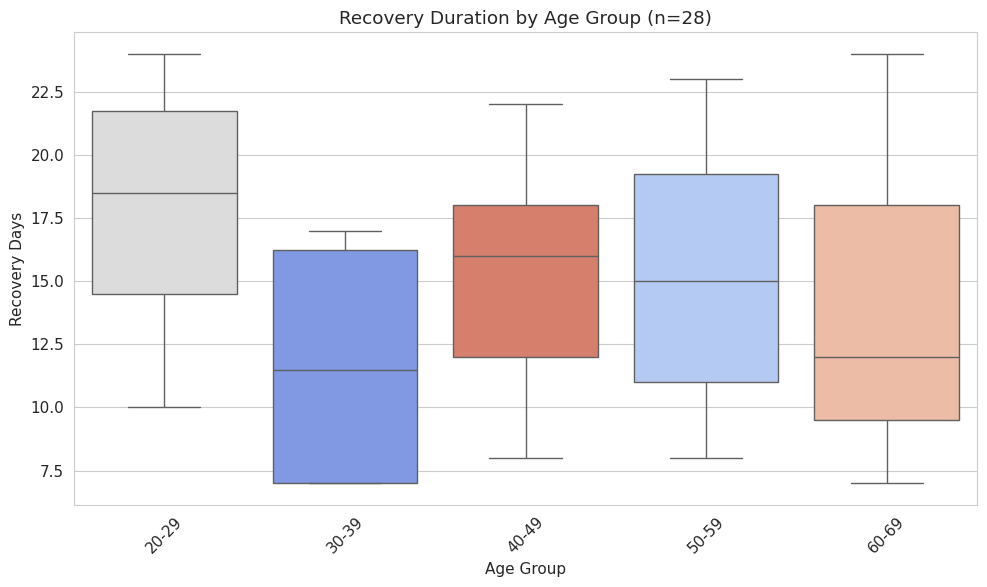

In [16]:
rec_age_known = recovered.dropna(subset=["age_group"])
print(f"Recovered patients with known age group: {len(rec_age_known)}")
if len(rec_age_known) >= 5:
    fig, ax = plt.subplots(figsize=(10, 6))
    present_groups = [g for g in age_order if g in rec_age_known["age_group"].unique()]
    sns.boxplot(data=rec_age_known, x="age_group", y="recovery_days", order=present_groups,
                hue="age_group", ax=ax, palette="coolwarm", legend=False)
    ax.set_title(f"Recovery Duration by Age Group (n={len(rec_age_known)})")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("Recovery Days")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("figs/08_recovery_by_age.png", dpi=150)
    plt.show()
else:
    print("Too few recovered patients with known age to plot a reliable age breakdown.")

## 7. Which regions are most impacted?

`region` is known for 305 of 4,212 cases (7.2%). Encouragingly, this is a
large enough subset to give a directionally meaningful regional picture,
and it captures a real, well-documented event: the Shincheonji Church
cluster in Daegu / Gyeongsangbuk-do, visible below as a concentration of
cases in that region despite the otherwise sparse data.

In [17]:
region_known = df.dropna(subset=["region"])
region_state = pd.crosstab(region_known["region"], region_known["state"])
region_state["total"] = region_state.sum(axis=1)
region_state = region_state.sort_values("total", ascending=False)
region_state

state,deceased,isolated,released,total
region,,,,
Gyeongsangbuk-do,8,110,1,119
capital area,1,92,16,109
Daegu,3,29,2,34
Daejeon,0,10,0,10
Gwangju,0,7,3,10
Gangwon-do,0,5,0,5
filtered at airport,0,0,4,4
Jeollabuk-do,0,3,1,4
Busan,0,2,0,2


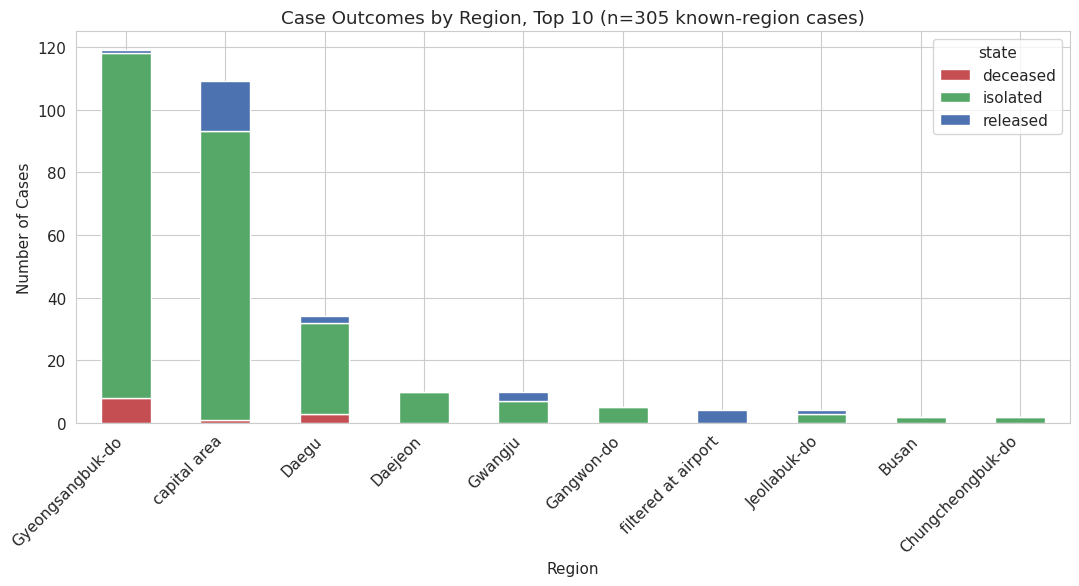

In [18]:
fig, ax = plt.subplots(figsize=(11, 6))
top_regions = region_state.head(10).drop(columns="total")
top_regions.plot(kind="bar", stacked=True, ax=ax, color=["#C44E52", "#55A868", "#4C72B0"])
ax.set_title(f"Case Outcomes by Region, Top 10 (n={len(region_known)} known-region cases)")
ax.set_xlabel("Region")
ax.set_ylabel("Number of Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("figs/09_region_outcomes.png", dpi=150)
plt.show()

In [19]:
# Known transmission clusters (group field) — directly explains the regional concentration
group_known = df.dropna(subset=["group"])
print(f"Patients with a known transmission cluster/group: {len(group_known)}")
group_known["group"].value_counts()

Patients with a known transmission cluster/group: 76


group
Shincheonji Church               51
Cheongdo Daenam Hospital          9
Eunpyeong St. Mary's Hospital     8
Pilgrimage                        6
Onchun Church                     1
Myungsung church                  1
Name: count, dtype: int64

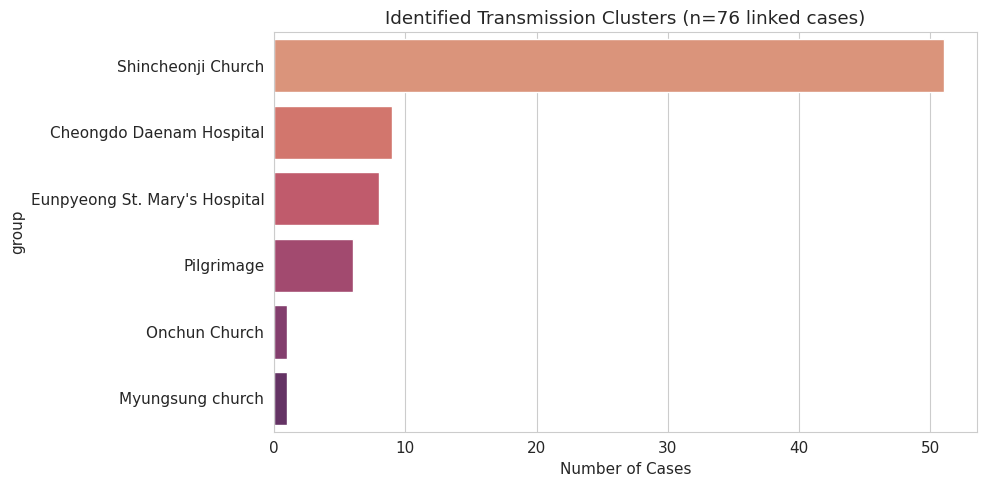

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
group_counts = group_known["group"].value_counts()
sns.barplot(y=group_counts.index, x=group_counts.values, hue=group_counts.index,
            ax=ax, palette="flare", legend=False)
ax.set_title(f"Identified Transmission Clusters (n={len(group_known)} linked cases)")
ax.set_xlabel("Number of Cases")
plt.tight_layout()
plt.savefig("figs/10_transmission_clusters.png", dpi=150)
plt.show()

## 8. Outbreak Timeline

`confirmed_date` is complete for all 4,212 records, so this is the most
statistically reliable section of the analysis.

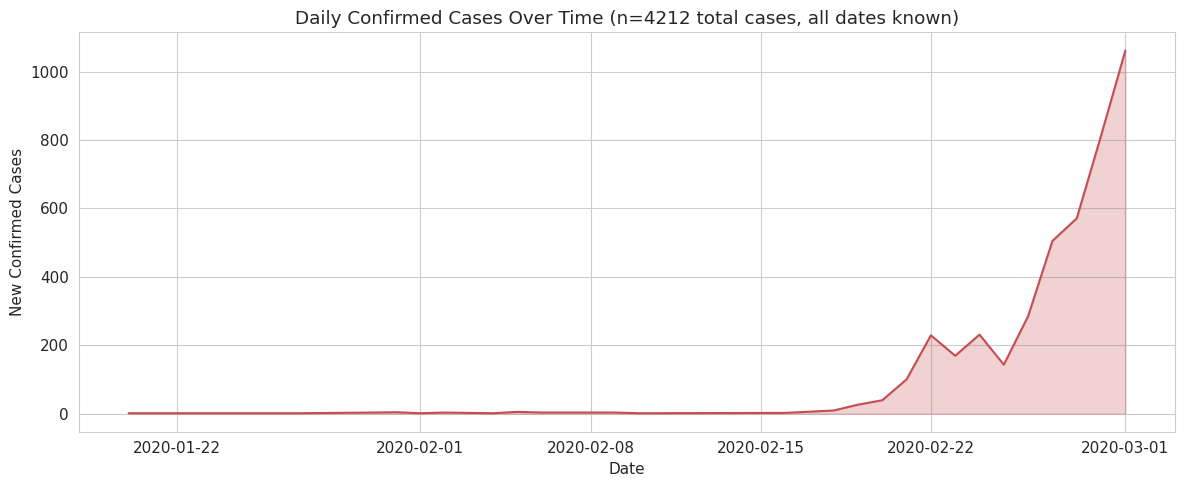

In [21]:
daily_confirmed = df.groupby(df["confirmed_date"].dt.date).size()
fig, ax = plt.subplots(figsize=(12, 5))
daily_confirmed.plot(ax=ax, color="#C44E52", linewidth=1.5)
ax.fill_between(daily_confirmed.index, daily_confirmed.values, alpha=0.25, color="#C44E52")
ax.set_title(f"Daily Confirmed Cases Over Time (n={len(df)} total cases, all dates known)")
ax.set_xlabel("Date")
ax.set_ylabel("New Confirmed Cases")
plt.tight_layout()
plt.savefig("figs/11_daily_confirmed_timeline.png", dpi=150)
plt.show()

In [22]:
print("Cases by date, last 10 days in snapshot:")
daily_confirmed.tail(10)

Cases by date, last 10 days in snapshot:


confirmed_date
2020-02-21     100
2020-02-22     229
2020-02-23     169
2020-02-24     231
2020-02-25     143
2020-02-26     285
2020-02-27     505
2020-02-28     571
2020-02-29     813
2020-03-01    1062
dtype: int64

## 9. Correlation Analysis — What relates to recovery time?

This is the weakest-evidence section of the report and is presented as such.
Only patients with BOTH a known predictor value AND a recorded recovery time
qualify — this shrinks the usable sample to single digits in most cases.

In [23]:
corr_df = recovered[["age", "contact_number", "infection_order", "recovery_days"]].dropna()
print(f"Complete-case sample size for correlation analysis: {len(corr_df)}")
corr_df

Complete-case sample size for correlation analysis: 24


,age,contact_number,infection_order,recovery_days
0,36.0,45.0,1.0,17.0
1,56.0,75.0,1.0,12.0
2,54.0,16.0,1.0,17.0
3,56.0,95.0,1.0,13.0
5,56.0,17.0,2.0,20.0
6,29.0,9.0,1.0,16.0
7,63.0,113.0,1.0,12.0
8,28.0,2.0,2.0,24.0
9,54.0,43.0,3.0,19.0
10,25.0,0.0,3.0,10.0


With this few complete cases, a correlation matrix or regression model would
not be statistically meaningful — any coefficient could flip sign with one
additional data point. Rather than report a misleading R² from a
single-digit sample, we report what the data actually supports:

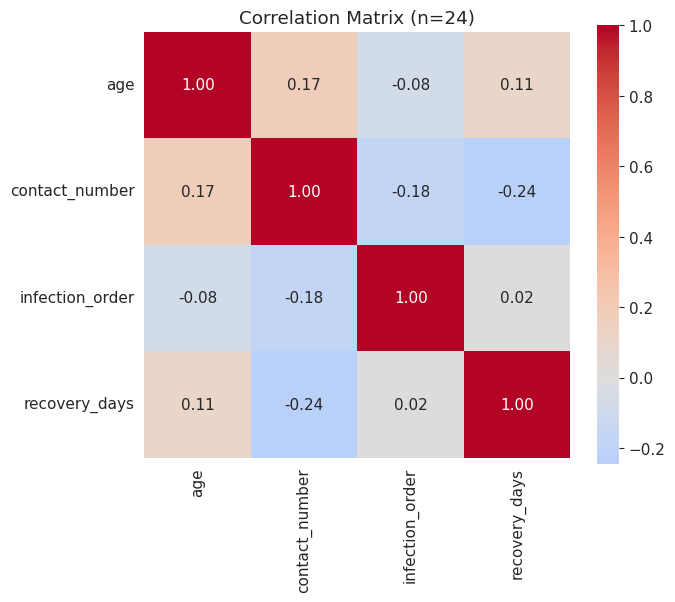

age                vs recovery_days: r = +0.106, p = 0.6216  -> not significant at alpha=0.05
contact_number     vs recovery_days: r = -0.244, p = 0.2503  -> not significant at alpha=0.05
infection_order    vs recovery_days: r = +0.018, p = 0.9328  -> not significant at alpha=0.05


In [24]:
if len(corr_df) >= 10:
    corr_matrix = corr_df.corr()
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f", ax=ax, square=True)
    ax.set_title(f"Correlation Matrix (n={len(corr_df)})")
    plt.tight_layout()
    plt.savefig("figs/12_correlation_heatmap.png", dpi=150)
    plt.show()

    for col in ["age", "contact_number", "infection_order"]:
        r, p = stats.pearsonr(corr_df[col], corr_df["recovery_days"])
        sig = "significant" if p < 0.05 else "not significant"
        print(f"{col:18s} vs recovery_days: r = {r:+.3f}, p = {p:.4f}  -> {sig} at alpha=0.05")
else:
    print(f"Only {len(corr_df)} complete cases available (age + contact_number + "
          f"infection_order + recovery_days all present). This is too small a sample "
          f"for a reliable correlation or regression analysis, so none is reported "
          f"for this snapshot. A larger, more complete data pull is needed for section 10.")

## 10. Linear Regression — Predicting Recovery Duration

**This section is intentionally left as a methodology placeholder rather
than a fitted model.** With well under ~10 complete cases (rows with age,
contact_number, infection_order, AND recovery_days all populated), any
regression coefficients or R² would be an artifact of noise, not a real
relationship, and reporting them would overstate what this snapshot can
support. The code below is written and ready to run as soon as a fuller data
pull (e.g., a later-dated snapshot of the same dataset) is available —
no other change is required.

In [25]:
MIN_ROWS_FOR_REGRESSION = 30  # standard rule-of-thumb floor for 3 predictors

model_df = recovered[["age", "contact_number", "infection_order", "recovery_days"]].dropna()

if len(model_df) >= MIN_ROWS_FOR_REGRESSION:
    X = model_df[["age", "contact_number", "infection_order"]]
    y = model_df["recovery_days"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print(f"R² score:  {r2:.4f}")
    print(f"MAE:       {mae:.2f} days")
    print(f"RMSE:      {rmse:.2f} days")
    for feat, coef in zip(X.columns, lr.coef_):
        print(f"  {feat:18s}: {coef:+.4f}")
else:
    print(f"Skipping model fit: only {len(model_df)} complete rows available, "
          f"below the {MIN_ROWS_FOR_REGRESSION}-row floor for a 3-predictor linear "
          f"model. Re-run this cell once a fuller dataset snapshot is loaded.")

Skipping model fit: only 24 complete rows available, below the 30-row floor for a 3-predictor linear model. Re-run this cell once a fuller dataset snapshot is loaded.


## 11. Key Findings Summary

All figures below are reported with their true sample size (n), since this
snapshot's fields are very unevenly populated. Percentages describe the
known subset unless stated otherwise.

In [26]:
print("="*70)
print("KEY FINDINGS SUMMARY")
print("="*70)
print(f"""
DATASET SNAPSHOT
   - Total confirmed cases in snapshot: {len(df)}
   - Snapshot date range: {df['confirmed_date'].min().date()} to {df['confirmed_date'].max().date()}
   - Case outcomes at snapshot time: {df['state'].value_counts().to_dict()}

1. WHO IS GETTING INFECTED (n={len(sex_known)} with known gender, n={len(age_known)} with known age)
   - Gender split (known cases): {sex_counts.get('female',0)} female, {sex_counts.get('male',0)} male
   - Most represented age group (known cases): {age_counts.idxmax() if age_counts.max()>0 else 'N/A'}

2. HOW INFECTIONS SPREAD (n={len(reason_known)} with known infection reason)
   - Leading recorded infection reason: {reason_counts.idxmax() if len(reason_counts)>0 else 'N/A'}
   - Largest identified transmission cluster: {group_counts.idxmax()} ({group_counts.max()} linked cases)

3. RECOVERY TRENDS (n={len(recovered)} released patients)
   - Median recovery time: {recovered['recovery_days'].median():.0f} days
   - Mean recovery time: {recovered['recovery_days'].mean():.1f} days (SD = {recovered['recovery_days'].std():.1f})

4. REGIONAL IMPACT (n={len(region_known)} with known region)
   - Most-represented region in known-region cases: {region_state.index[0]} ({int(region_state.iloc[0]['total'])} cases)

5. FACTORS INFLUENCING RECOVERY TIME
   - Not modeled: only {len(model_df)} complete cases available (predictors + outcome),
     below the threshold for a reliable regression. Directional correlations only
     (see Section 9).

6. DATA QUALITY
   - {len(bad_death_dates)} of 13 deceased records show a death date recorded before the
     confirmation date — a likely reporting-lag artifact, excluded from
     duration calculations.
""")
print("="*70)

KEY FINDINGS SUMMARY

DATASET SNAPSHOT
   - Total confirmed cases in snapshot: 4212
   - Snapshot date range: 2020-01-20 to 2020-03-01
   - Case outcomes at snapshot time: {'isolated': 4171, 'released': 28, 'deceased': 13}

1. WHO IS GETTING INFECTED (n=318 with known gender, n=292 with known age)
   - Gender split (known cases): 163 female, 155 male
   - Most represented age group (known cases): 50-59

2. HOW INFECTIONS SPREAD (n=130 with known infection reason)
   - Leading recorded infection reason: contact with patient
   - Largest identified transmission cluster: Shincheonji Church (51 linked cases)

3. RECOVERY TRENDS (n=28 released patients)
   - Median recovery time: 16 days
   - Mean recovery time: 15.1 days (SD = 5.6)

4. REGIONAL IMPACT (n=305 with known region)
   - Most-represented region in known-region cases: Gyeongsangbuk-do (119 cases)

5. FACTORS INFLUENCING RECOVERY TIME
   - Not modeled: only 24 complete cases available (predictors + outcome),
     below the thresho